# HW3

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## A

In [61]:
df = pd.read_csv("wpbc.data", header=None)

print(df.shape)
print(df.head())

(198, 35)
       0  1    2      3      4       5       6        7       8       9   ...  \
0  119513  N   31  18.02  27.60  117.50  1013.0  0.09489  0.1036  0.1086  ...   
1    8423  N   61  17.99  10.38  122.80  1001.0  0.11840  0.2776  0.3001  ...   
2  842517  N  116  21.37  17.44  137.50  1373.0  0.08836  0.1189  0.1255  ...   
3  843483  N  123  11.42  20.38   77.58   386.1  0.14250  0.2839  0.2414  ...   
4  843584  R   27  20.29  14.34  135.10  1297.0  0.10030  0.1328  0.1980  ...   

       25      26      27      28      29      30      31       32   33  34  
0  139.70  1436.0  0.1195  0.1926  0.3140  0.1170  0.2677  0.08113  5.0   5  
1  184.60  2019.0  0.1622  0.6656  0.7119  0.2654  0.4601  0.11890  3.0   2  
2  159.10  1949.0  0.1188  0.3449  0.3414  0.2032  0.4334  0.09067  2.5   0  
3   98.87   567.7  0.2098  0.8663  0.6869  0.2575  0.6638  0.17300  2.0   0  
4  152.20  1575.0  0.1374  0.2050  0.4000  0.1625  0.2364  0.07678  3.5   0  

[5 rows x 35 columns]


## B

In [62]:
X = df.iloc[:, 3:35]
y = df.iloc[:, 1]

print("Xshape:", X.shape)
print("yshape:", y.shape)

non_recurrent = df[df.iloc[:, 1] == 'N']
recurrent = df[df.iloc[:, 1] == 'R']

print("non-recurrent:", len(non_recurrent))
print("recurrent:", len(recurrent))


Xshape: (198, 32)
yshape: (198,)
non-recurrent: 151
recurrent: 47


In [63]:
train_N = non_recurrent.iloc[:130]
train_R = recurrent.iloc[:37]
record_197 = df.iloc[196:197]
train_df = pd.concat([train_N, train_R, record_197], axis=0)
test_df = df.drop(train_df.index)

X_train = train_df.iloc[:, 3:35]
y_train = train_df.iloc[:, 1]

X_test = test_df.iloc[:, 3:35]
y_test = test_df.iloc[:, 1]

y_train = y_train.map({'N': 0, 'R': 1})
y_test = y_test.map({'N': 0, 'R': 1})

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (168, 32)
y_train: (168,)
X_test : (30, 32)
y_test : (30,)


## C

In [64]:
print((train_df == '?').sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    4
dtype: int64


In [65]:
train_df.iloc[:, 34] = pd.to_numeric(
    train_df.iloc[:, 34],
    errors='coerce'
)

median = train_df.iloc[:, 34].median()

train_df.iloc[:, 34] = train_df.iloc[:, 34].fillna(median)

print((train_df == '?').sum())

X_train = train_df.iloc[:, 3:35]

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
dtype: int64


## D

In [66]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

GaussianNB()

In [67]:
y_train_pre = nb.predict(X_train)
y_test_pre = nb.predict(X_test)
y_train_prob = nb.predict_proba(X_train)[:,1]
y_test_prob = nb.predict_proba(X_test)[:,1]

In [68]:
from sklearn.metrics import confusion_matrix

cm_train = confusion_matrix(y_train, y_train_pre)
cm_test = confusion_matrix(y_test, y_test_pre)

print("Train Confusion Matrix：")
print(cm_train)

print("\nTest Confusion Matrix：")
print(cm_test)

Train Confusion Matrix：
[[98 32]
 [20 18]]

Test Confusion Matrix：
[[14  7]
 [ 6  3]]


In [69]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Train Precision:",precision_score(y_train,y_train_pre))
print("Train Recall:",recall_score(y_train,y_train_pre))
print("Train F1:",f1_score(y_train,y_train_pre))
print("\n")
print("Test Precision:",precision_score(y_test,y_test_pre))
print("Test Recall:",recall_score(y_test,y_test_pre))
print("Test F1:",f1_score(y_test,y_test_pre))

Train Precision: 0.36
Train Recall: 0.47368421052631576
Train F1: 0.40909090909090906


Test Precision: 0.3
Test Recall: 0.3333333333333333
Test F1: 0.3157894736842105


In [70]:
from sklearn.metrics import roc_auc_score

train_auc = roc_auc_score( y_train,y_train_prob)

test_auc = roc_auc_score( y_test, y_test_prob)

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)

Train AUC: 0.6757085020242914
Test AUC: 0.5555555555555556


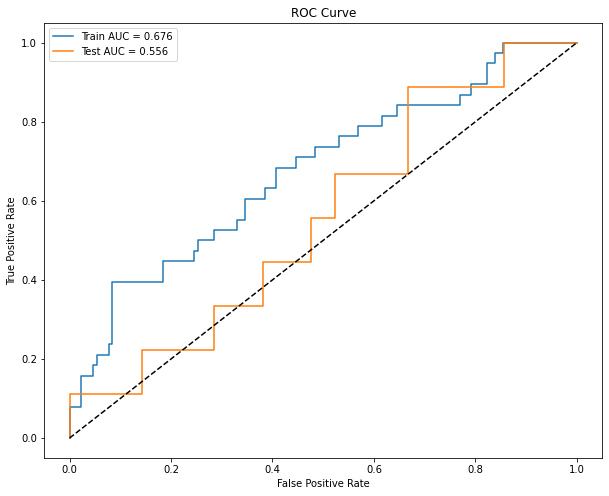

In [71]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(10,8))

plt.plot(fpr_train,tpr_train,label=f"Train AUC = {train_auc:.3f}")
plt.plot(fpr_test,tpr_test,label=f"Test AUC = {test_auc:.3f}")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

SMOTE

In [72]:
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [73]:
rus = RandomUnderSampler(sampling_strategy={major_class: 90},random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)
print("After undersampling:", Counter(y_under))

smote = SMOTE(sampling_strategy={minor_class: 90},k_neighbors=5,random_state=42)
X_res, y_res = smote.fit_resample(X_under, y_under)
print("After SMOTE:", Counter(y_res))

After undersampling: Counter({0: 90, 1: 38})
After SMOTE: Counter({0: 90, 1: 90})


In [74]:
nb_smote = GaussianNB()
nb_smote.fit(X_res, y_res)

y_train_pred = nb_smote.predict(X_res)
y_train_prob = nb_smote.predict_proba(X_res)[:, 1]
y_test_pred = nb_smote.predict(X_test)
y_test_prob = nb_smote.predict_proba(X_test)[:, 1]

In [75]:
print("TRAIN (after SMOTE)")
print("Confusion Matrix:")
print(confusion_matrix(y_res, y_train_pred))
print("Precision:", precision_score(y_res, y_train_pred))
print("Recall:", recall_score(y_res, y_train_pred))
print("F1:", f1_score(y_res, y_train_pred))
print("AUC:", roc_auc_score(y_res, y_train_prob))

print("\nTEST")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))
print("AUC:", roc_auc_score(y_test, y_test_prob))

TRAIN (after SMOTE)
Confusion Matrix:
[[64 26]
 [31 59]]
Precision: 0.6941176470588235
Recall: 0.6555555555555556
F1: 0.6742857142857143
AUC: 0.7472839506172839

TEST
Confusion Matrix:
[[14  7]
 [ 5  4]]
Precision: 0.36363636363636365
Recall: 0.4444444444444444
F1: 0.39999999999999997
AUC: 0.6931216931216931


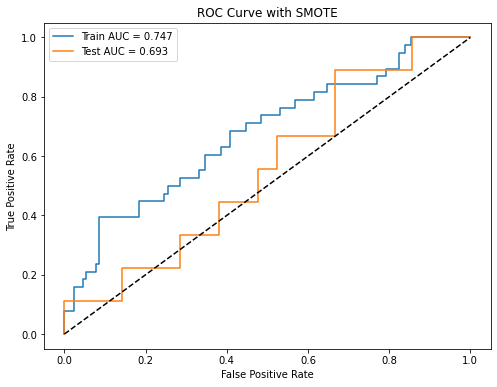

In [76]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {roc_auc_score(y_res, y_train_prob):.3f}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {roc_auc_score(y_test, y_test_prob):.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with SMOTE")
plt.legend()
plt.show()

SMOTE helped. The test AUC increased from 0.556 to 0.693, and the classifier became more effective at detecting recurrent cases. 
Therefore, balancing the training data improved the overall predictive performance.

## E